<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QForce003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Initialization cell
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(0, 2*np.pi, N)
omega = 1.0
epsilon = 0.01

# Oscillatory field
field = epsilon * np.sin(omega * x)

# Particle packet: Gaussian bump
def gaussian_packet(x, center, sigma, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * sigma**2))

packet = gaussian_packet(x, center=np.pi, sigma=0.5, amplitude=0.1)

# Combined lattice
lattice = field + packet
history = [lattice.copy()]


In [2]:
# Propagation cell
def evolve_packet(lattice, dt=0.1):
    new = lattice.copy()
    for i in range(1, len(lattice)-1):
        gradient = lattice[i+1] - lattice[i-1]
        new[i] += dt * gradient * lattice[i]
    return new

for t in range(1000):
    lattice = evolve_packet(lattice)
    if t % 50 == 0:
        history.append(lattice.copy())


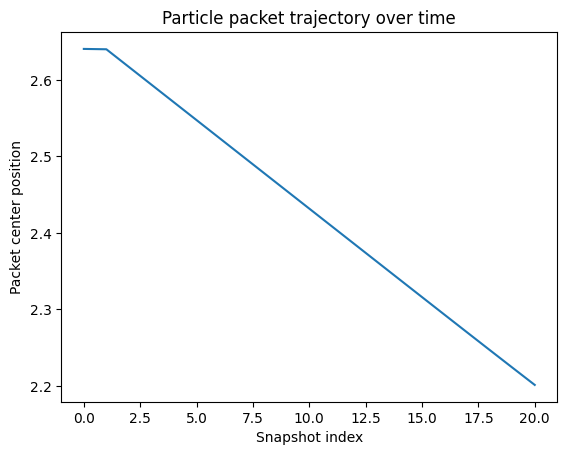

In [3]:
# Packet center tracking
def center_of_mass(lattice):
    return np.sum(x * lattice) / np.sum(lattice)

centers = [center_of_mass(h) for h in history]

plt.plot(range(len(centers)), centers)
plt.xlabel("Snapshot index")
plt.ylabel("Packet center position")
plt.title("Particle packet trajectory over time")
plt.show()


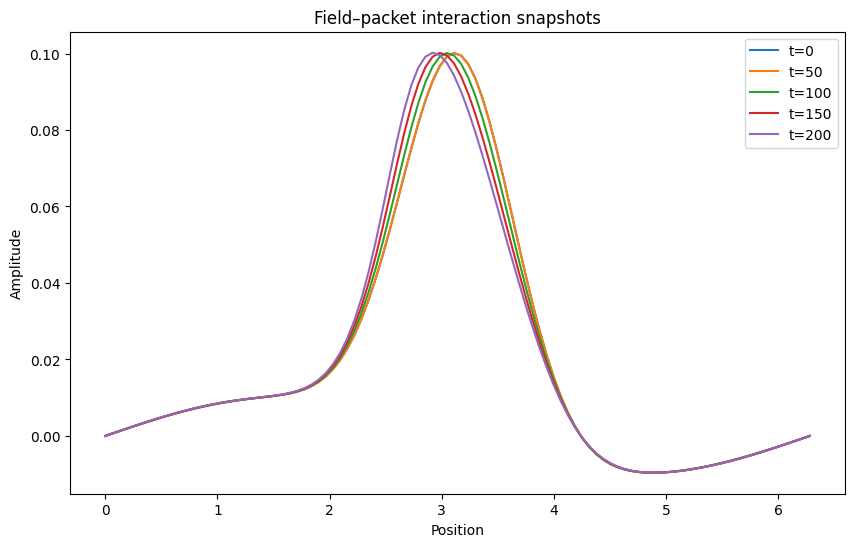

In [4]:
# Wavefront snapshots
plt.figure(figsize=(10,6))
for idx, h in enumerate(history[:5]):
    plt.plot(x, h, label=f"t={idx*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Field–packet interaction snapshots")
plt.legend()
plt.show()
